# ADIS Outbreaks Basic EDA

Self-contained first-pass EDA for HPAI records in `data/structured/adis/adis-outbreaks-20260519.csv`. This notebook follows the same structure as the WAHIS and EMPRES-i EDA notebooks while keeping ADIS-specific outbreak burden, diagnostic, status, and administrative fields.


## Setup

Shared plotting, display, and helper functions used throughout the notebook.


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt

plt.style.use("ggplot")

params = {
    "text.color": (0.25, 0.25, 0.25),
    "figure.figsize": [16, 9],
}

plt.rcParams.update(params)

# Get colors from default theme.
DEFAULT_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

import seaborn as sns
# sns.set()


from pathlib import Path

import pandas as pd


pd.options.display.max_columns = 120
pd.options.mode.chained_assignment = None
pd.options.display.max_rows = 500
pd.options.display.max_seq_items = 500


NA_VALUES = ["NaN", "nan", "", ";"]


def find_data_path(*candidates: str) -> Path:
    paths = [Path(candidate) for candidate in candidates]
    path = next((candidate for candidate in paths if candidate.exists()), None)
    if path is None:
        tried = "\n".join(str(candidate) for candidate in paths)
        raise FileNotFoundError(f"Could not find source CSV. Tried:\n{tried}")
    return path


def schema_summary(data: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dtype": data.dtypes.astype(str),
            "missing": data.isna().sum(),
            "missing_pct": data.isna().mean().mul(100).round(1),
            "n_unique": data.nunique(dropna=True),
        }
    ).sort_values(["missing_pct", "n_unique"], ascending=[False, False])


def top_counts(data: pd.DataFrame, column: str, n: int = 15) -> pd.DataFrame:
    return (
        data[column]
        .fillna("Missing")
        .value_counts(dropna=False)
        .head(n)
        .rename_axis(column)
        .reset_index(name="records")
    )


def plot_top_counts(
    data: pd.DataFrame, specs: list[tuple[str, int, str]], cols: int = 2
) -> None:
    rows = -(-len(specs) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 4.8 * rows), squeeze=False)
    for axis, (column, n, title) in zip(axes.ravel(), specs):
        counts = top_counts(data, column, n=n)
        sns.barplot(data=counts, y=column, x="records", ax=axis, color="#4C78A8")
        axis.set_title(title)
        axis.set_xlabel("Records")
        axis.set_ylabel("")
    for axis in axes.ravel()[len(specs) :]:
        axis.set_visible(False)
    plt.tight_layout()


def date_coverage(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "date_column": columns,
            "min_date": [data[column].min() for column in columns],
            "max_date": [data[column].max() for column in columns],
            "missing": [data[column].isna().sum() for column in columns],
            "missing_pct": [
                round(data[column].isna().mean() * 100, 1) for column in columns
            ],
        }
    )


def monthly_counts(
    data: pd.DataFrame, date_column: str, label: str = "records"
) -> pd.DataFrame:
    return (
        data.dropna(subset=[date_column])
        .assign(
            month=lambda frame: frame[date_column].dt.to_period("M").dt.to_timestamp()
        )
        .groupby("month")
        .size()
        .rename(label)
        .reset_index()
    )


def monthly_counts_by_category(
    data: pd.DataFrame,
    date_column: str,
    category_column: str,
    top_n: int = 6,
    label: str = "records",
) -> pd.DataFrame:
    top_values = top_counts(data, category_column, n=top_n)[category_column]
    return (
        data[data[category_column].isin(top_values)]
        .dropna(subset=[date_column])
        .assign(
            month=lambda frame: frame[date_column].dt.to_period("M").dt.to_timestamp()
        )
        .groupby(["month", category_column])
        .size()
        .rename(label)
        .reset_index()
    )


def country_disease_matrix(
    data: pd.DataFrame,
    country_column: str,
    disease_column: str,
    country_n: int = 12,
    disease_n: int = 8,
) -> pd.DataFrame:
    top_countries = top_counts(data, country_column, n=country_n)[country_column]
    top_diseases = top_counts(data, disease_column, n=disease_n)[disease_column]
    filtered = data[
        data[country_column].isin(top_countries)
        & data[disease_column].isin(top_diseases)
    ]
    return pd.crosstab(filtered[country_column], filtered[disease_column])

import contextily as cx
import geopandas as gpd

BASEMAP_SOURCE = cx.providers.CartoDB.Positron


def plot_event_map(
    data: pd.DataFrame,
    longitude_column: str,
    latitude_column: str,
    color_column: str,
    title: str,
    sample_n: int | None = None,
    marker_size: float = 18,
    alpha: float = 0.65,
) -> gpd.GeoDataFrame:
    geo_data = data.dropna(subset=[longitude_column, latitude_column]).copy()
    if sample_n is not None and len(geo_data) > sample_n:
        geo_data = geo_data.sample(sample_n, random_state=42)

    gdf = gpd.GeoDataFrame(
        geo_data,
        geometry=gpd.points_from_xy(geo_data[longitude_column], geo_data[latitude_column]),
        crs='EPSG:4326',
    ).to_crs(epsg=3857)

    fig, axis = plt.subplots(figsize=(11, 9))
    gdf.plot(
        ax=axis,
        column=color_column,
        categorical=True,
        legend=True,
        markersize=marker_size,
        alpha=alpha,
        linewidth=0,
    )
    cx.add_basemap(axis, source=BASEMAP_SOURCE, attribution_size=7)
    axis.set_title(title)
    axis.set_axis_off()
    plt.tight_layout()
    return gdf


## Load Data

ADIS uses semicolon-delimited CSV exports, decimal commas for numeric fields, and ISO-style dates.


In [2]:
DATA_PATH = find_data_path(
    "../data/structured/adis/adis-outbreaks-20260519.csv",
    "data/structured/adis/adis-outbreaks-20260519.csv",
)

raw_df = pd.read_csv(
    DATA_PATH,
    sep=";",
    decimal=",",
    na_values=NA_VALUES,
    keep_default_na=True,
    low_memory=False,
)

print(f"Loaded {len(raw_df):,} rows and {raw_df.shape[1]:,} columns from {DATA_PATH}")
raw_df.head()

Loaded 1,423 rows and 46 columns from ../data/structured/adis/adis-outbreaks-20260519.csv


,Reference,National reference,Country/Territory,Typ,Disease name,Disease type,Epidemiological unit,Submitted on,Modified on,Administrative division level 1,Administrative division level 2,Administrative division level 3,Outbreak occurring inside an already restricted zone,Latitude,Longitude,Approximate location,Location,Wildlife type 1,Production Type 1,Water type 1,Production system 1,Measuring unit 1,Susceptible 1,Cases 1,Dead 1,Killed 1,Slaughtered 1,Vaccinated 1,Outbreak year,Suspicion/Start date,Confirmation date,End date,Status Continuing/Resolved,Suspicion,Clinical signs,Diagnostic tests,Necropsy,Category 1,Subcategory 1,Test name 1,Test type 1,Laboratory type 1,Species 1,Result date 1,Result type 1,Pertinence
0,IT-SHB-2025-xghqg,SHB_2025_0016-zutgb,Italien,Secondary,Aethina tumida (Inf. with)(Small hive beetle)(...,NaN,Apiary,2026-05-13,2026-05-13,Sicily,Messina,Messina,NaN,38.209307,15.521267,False,Messina,NaN,NaN,NaN,NaN,Hives,1.0,1.0,0.0,0.0,NaN,NaN,2025,2025-12-10,2025-12-24,NaN,Continuing,False,True,True,False,Other (other than pathogen or antibody detection),Other (tests other than pathogen or antibody d...,Morphological identification,Laboratory,National Reference Laboratory,Bees,2025-12-24,Positive,EU and WOAH
1,DE-HPAI(NON-P)-2026-xsyaz,26-015-a0jke,Deutschland,Primary,HPAI(NON-P) in Wild Birds,H5N1,Not applicable,2026-05-19,2026-05-19,Nordrhein-Westfalen,Ennepe-Ruhr-Kreis,Witten,True,51.410000,7.350000,True,Witten,Wild,NaN,NaN,NaN,Tiere,NaN,1.0,1.0,0.0,0.0,0.0,2026,2026-01-27,2026-01-30,2026-01-30,Resolved,False,False,True,False,Pathogen detection,Nucleic acid detection,Real-time polymerase chain reaction (real-time...,Laboratory,Private Laboratory,Anser anser,2026-01-30,Positive,EU and WOAH
2,DE-HPAI(NON-P)-2026-yy25e,26-015-mqw20,Deutschland,Primary,HPAI(NON-P) in Wild Birds,H5N1,Not applicable,2026-04-20,2026-04-20,Hessen,Hersfeld-Rotenburg,Heringen (Werra),True,50.910000,10.010000,True,Heringen (Werra),Wild,NaN,NaN,NaN,Tiere,NaN,1.0,1.0,0.0,0.0,0.0,2026,2026-01-19,2026-02-02,2026-04-17,Resolved,False,False,True,False,Pathogen detection,Nucleic acid detection,Polymerase chain reaction (PCR),Laboratory,Private Laboratory,Anserinae (unidentified),2026-01-31,Positive,EU and WOAH
3,IS-HPAI(NON-P)-2026-xvb7r,WB-r4a6d,Island,Primary,HPAI(NON-P) in Wild Birds,H5N1,Not applicable,2026-05-05,2026-05-05,Höfuðborgarsvæði,Reykjavík,NaN,False,64.139686,-21.964240,False,Reykjavík,Wild,NaN,NaN,NaN,Tiere,NaN,1.0,1.0,0.0,0.0,0.0,2026,2026-02-06,2026-02-16,NaN,Continuing,False,True,True,False,Pathogen detection,Nucleic acid detection,Polymerase chain reaction (PCR),Laboratory,National Reference Laboratory,Anser anser,2026-02-16,Positive,EU and WOAH
4,IS-HPAI(NON-P)-2026-65set,WB-nvcax,Island,Primary,HPAI(NON-P) in Wild Birds,H5N1,Not applicable,2026-05-06,2026-05-06,Höfuðborgarsvæði,Reykjavík,NaN,False,64.155561,-21.962850,False,Reykjavík,Wild,NaN,NaN,NaN,Tiere,NaN,1.0,1.0,NaN,NaN,NaN,2026,2026-02-02,2026-02-24,NaN,Continuing,False,True,True,False,Pathogen detection,Nucleic acid detection,Polymerase chain reaction (PCR),Laboratory,National Reference Laboratory,Anser anser,2026-02-24,Positive,EU and WOAH


## Clean Working Copy

Parse dates, numeric burden fields, boolean-like flags, filter to HPAI records, and add derived delay/burden metrics.


In [3]:
df = raw_df.copy()
df.columns = df.columns.str.strip()

HPAI_MATCH_COLUMNS = ["Disease name", "Disease type"]
hpai_mask = pd.Series(False, index=df.index)
for column in HPAI_MATCH_COLUMNS:
    hpai_mask |= (
        df[column]
        .fillna("")
        .str.contains(
            "HPAI|high pathogenic|high pathogenicity avian influenza",
            case=False,
            regex=True,
        )
    )

df = df.loc[hpai_mask].copy()
print(f"Filtered to {len(df):,} HPAI records from {len(raw_df):,} total ADIS records.")

DATE_COLUMNS = [
    "Submitted on",
    "Modified on",
    "Suspicion/Start date",
    "Confirmation date",
    "End date",
    "Result date 1",
]
for column in DATE_COLUMNS:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

NUMERIC_COLUMNS = [
    "Latitude",
    "Longitude",
    "Susceptible 1",
    "Cases 1",
    "Dead 1",
    "Killed 1",
    "Slaughtered 1",
    "Vaccinated 1",
    "Outbreak year",
]
for column in NUMERIC_COLUMNS:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

BOOLEAN_LIKE_COLUMNS = [
    "Outbreak occurring inside an already restricted zone",
    "Approximate location",
    "Suspicion",
    "Clinical signs",
    "Diagnostic tests",
    "Necropsy",
]
for column in BOOLEAN_LIKE_COLUMNS:
    if column in df.columns:
        df[column] = df[column].map({"true": True, "false": False})

df["confirmation_delay_days"] = (
    df["Confirmation date"] - df["Suspicion/Start date"]
).dt.days
df["submission_delay_days"] = (df["Submitted on"] - df["Confirmation date"]).dt.days
df["outbreak_duration_days"] = (df["End date"] - df["Suspicion/Start date"]).dt.days
df["total_affected_or_removed"] = df[
    ["Cases 1", "Dead 1", "Killed 1", "Slaughtered 1"]
].sum(axis=1, min_count=1)

duplicate_summary = pd.Series(
    {
        "duplicate_reference": df["Reference"].duplicated().sum(),
        "duplicate_national_reference": df["National reference"].duplicated().sum(),
    }
)

display(df.dtypes.to_frame("dtype"))
display(duplicate_summary.to_frame("count"))

Filtered to 204 HPAI records from 1,423 total ADIS records.


,dtype
Reference,str
National reference,str
Country/Territory,str
Typ,str
Disease name,str
Disease type,str
Epidemiological unit,str
Submitted on,datetime64[us]
Modified on,datetime64[us]
Administrative division level 1,str


,count
duplicate_reference,0
duplicate_national_reference,12


## Dataset Overview And Completeness


In [4]:
overview = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "countries": [df["Country/Territory"].nunique()],
        "diseases": [df["Disease name"].nunique()],
        "species": [df["Species 1"].nunique()],
        "continuing_statuses": [df["Status Continuing/Resolved"].nunique()],
        "first_suspicion_date": [df["Suspicion/Start date"].min()],
        "last_suspicion_date": [df["Suspicion/Start date"].max()],
    }
)

display(overview)
display(schema_summary(df).head(35))
display(date_coverage(df, [column for column in DATE_COLUMNS if column in df.columns]))

,rows,columns,countries,diseases,species,continuing_statuses,first_suspicion_date,last_suspicion_date
0,204,50,16,3,31,2,2026-01-19,2026-05-16


,dtype,missing,missing_pct,n_unique
Outbreak occurring inside an already restricted zone,object,204,100.0,0
Approximate location,object,204,100.0,0
Water type 1,float64,204,100.0,0
Production system 1,str,204,100.0,0
Suspicion,object,204,100.0,0
Clinical signs,object,204,100.0,0
Diagnostic tests,object,204,100.0,0
Necropsy,object,204,100.0,0
Susceptible 1,float64,139,68.1,64
Production Type 1,str,139,68.1,2


,date_column,min_date,max_date,missing,missing_pct
0,Submitted on,2026-04-20,2026-05-19,0,0.0
1,Modified on,2026-04-20,2026-05-19,0,0.0
2,Suspicion/Start date,2026-01-19,2026-05-16,0,0.0
3,Confirmation date,2026-01-30,2026-05-19,0,0.0
4,End date,2026-01-30,2026-05-19,65,31.9
5,Result date 1,2026-01-30,2026-05-19,6,2.9


## Top Categories


In [5]:
CATEGORY_COLUMNS = [
    "Country/Territory",
    "Disease name",
    "Disease type",
    "Species 1",
    "Status Continuing/Resolved",
    "Epidemiological unit",
]

for column in CATEGORY_COLUMNS:
    display(top_counts(df, column, n=20))

,Country/Territory,records
0,Deutschland,84
1,Polen,65
2,Österreich,11
3,Norwegen,8
4,Frankreich,6
5,Niederlande,6
6,Dänemark,6
7,Island,4
8,Finnland,4
9,Estland,2


,Disease name,records
0,HPAI(NON-P) in Wild Birds,139
1,High pathogenicity avian influenza viruses (In...,58
2,HPAI(NON-P) in Captive Birds,7


,Disease type,records
0,H5N1,202
1,H5N5,2


,Species 1,records
0,Birds,64
1,Anser anser,49
2,Cygnus olor,22
3,Buteo buteo,7
4,Accipitridae (incognita),6
5,Missing,6
6,Branta leucopsis,6
7,Branta canadensis,5
8,Anatidae (incognita),4
9,Ciconia ciconia,4


,Status Continuing/Resolved,records
0,Resolved,139
1,Continuing,65


,Epidemiological unit,records
0,Not applicable,104
1,Farm,58
2,Other,32
3,Backyard,6
4,Body of water,2
5,Natural park,2


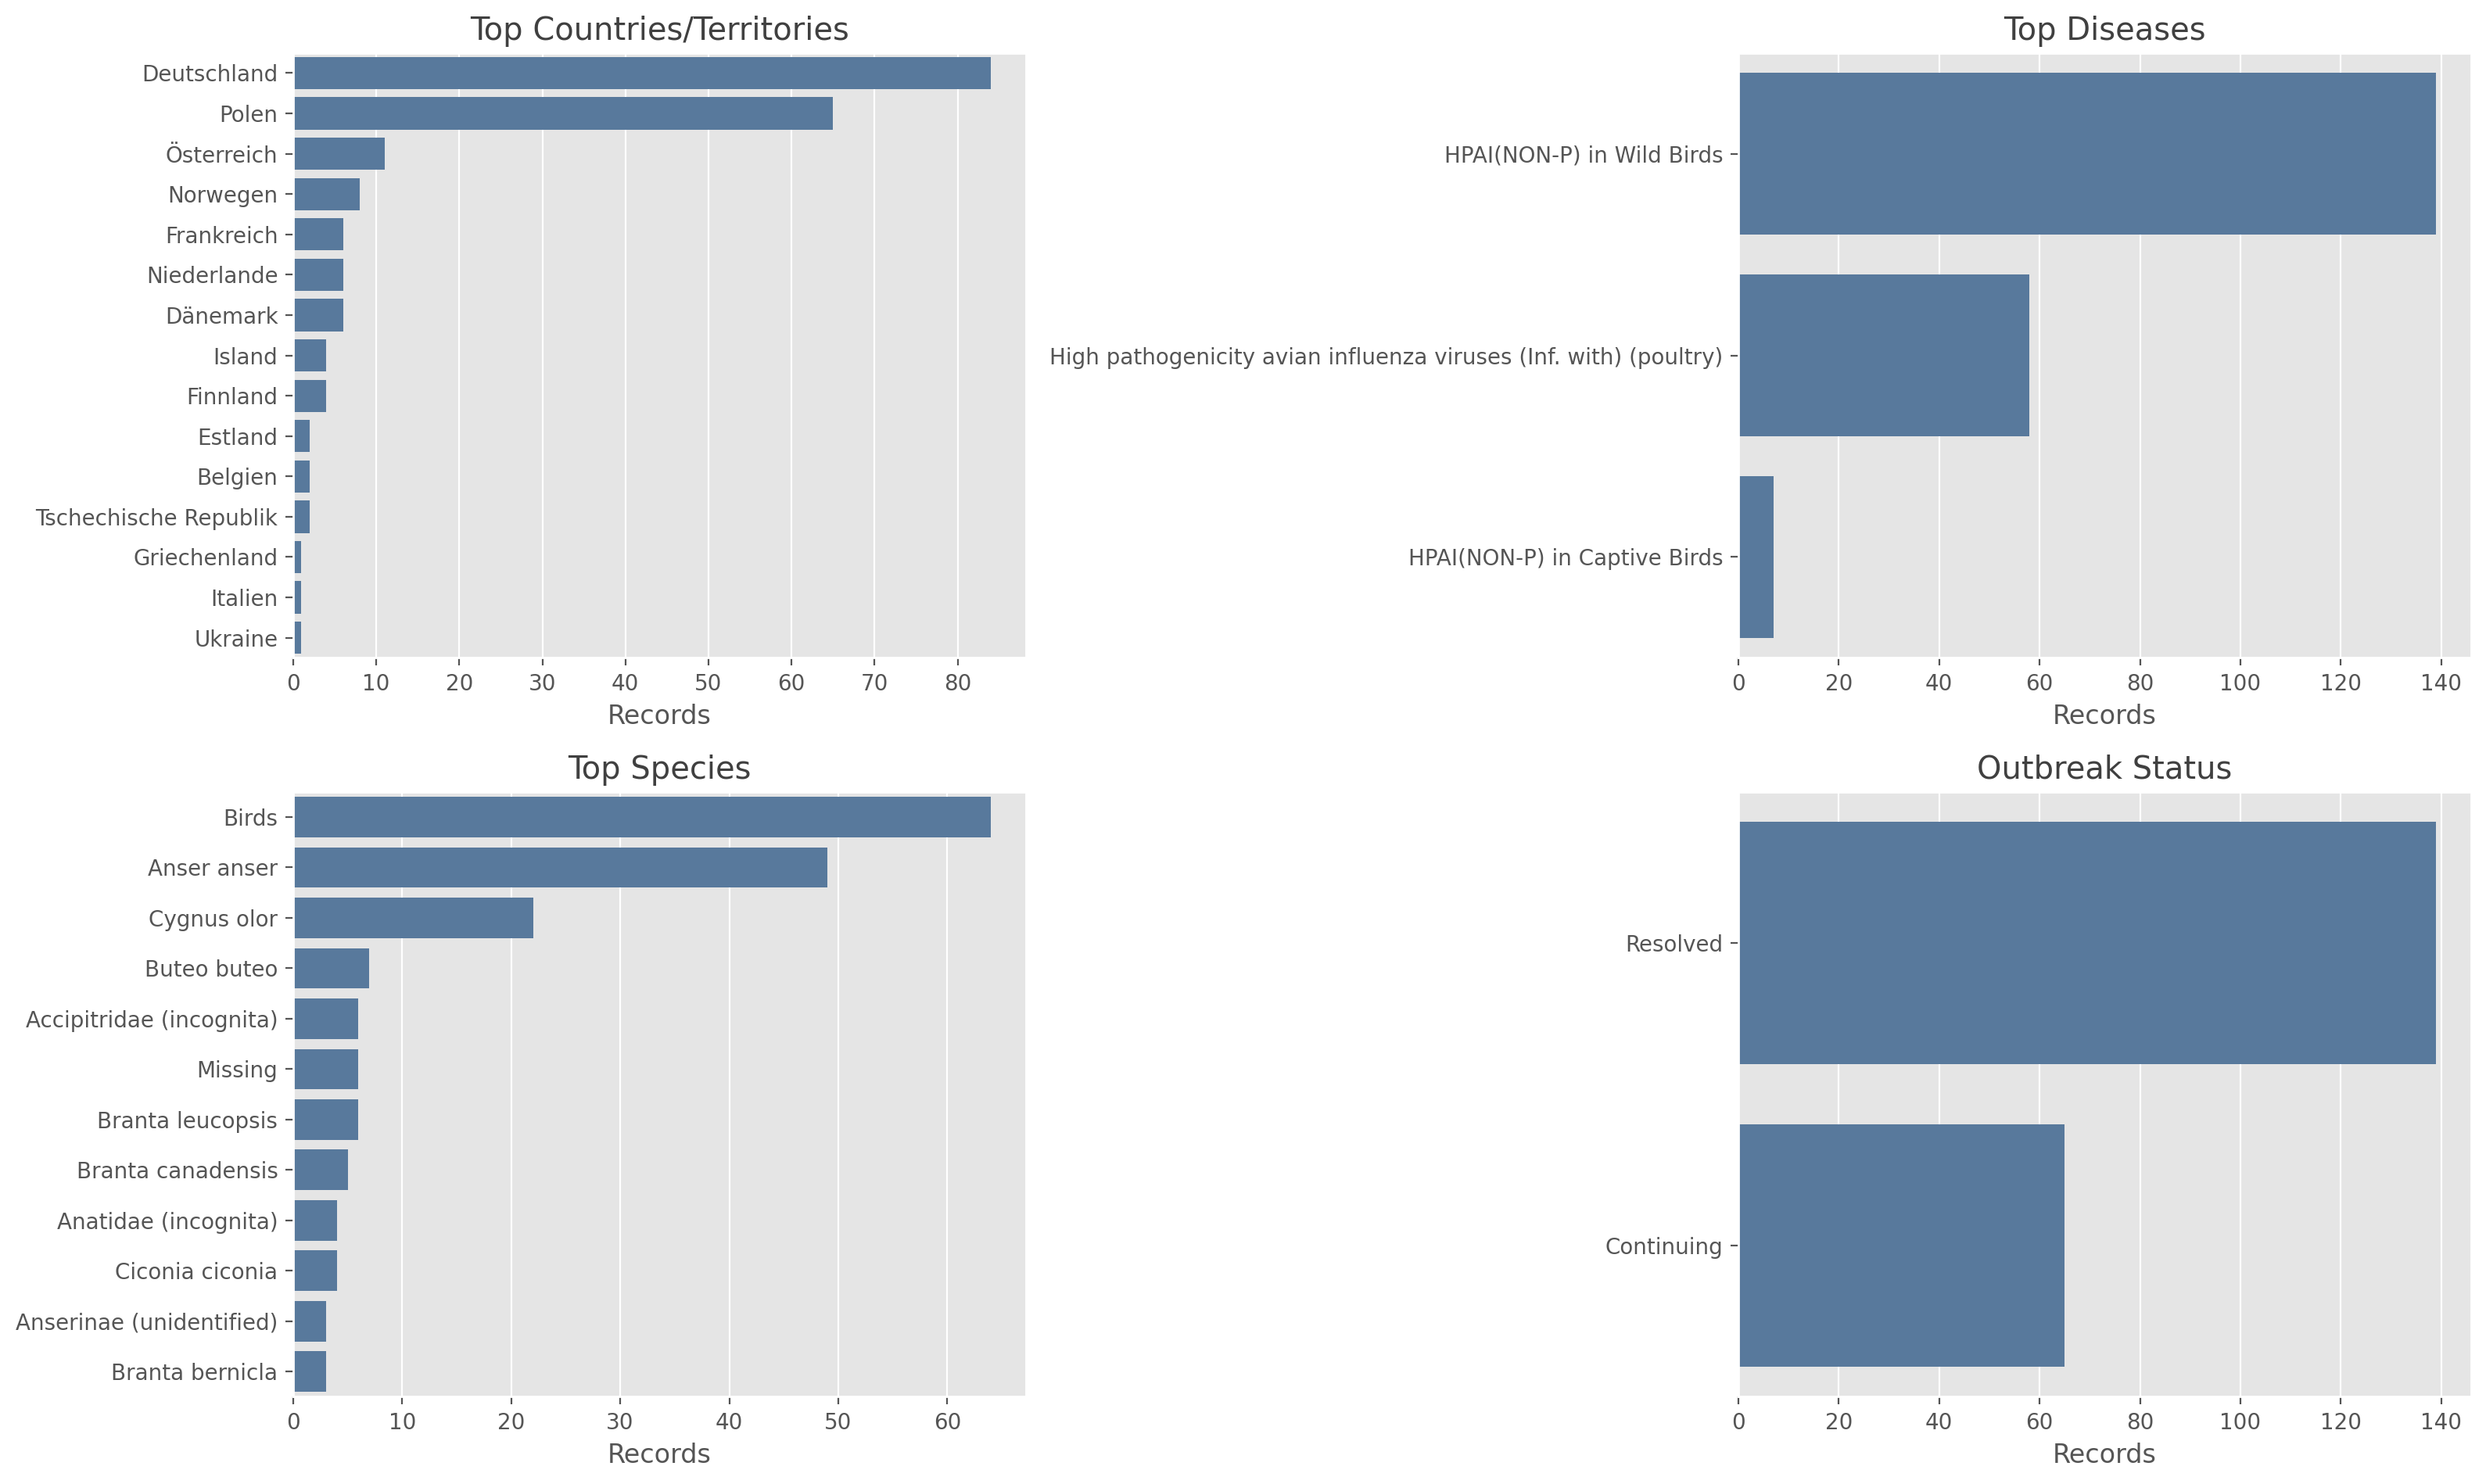

In [6]:
plot_top_counts(
    df,
    [
        ("Country/Territory", 15, "Top Countries/Territories"),
        ("Disease name", 12, "Top Diseases"),
        ("Species 1", 12, "Top Species"),
        ("Status Continuing/Resolved", 8, "Outbreak Status"),
    ],
)

## Time Coverage And Trends


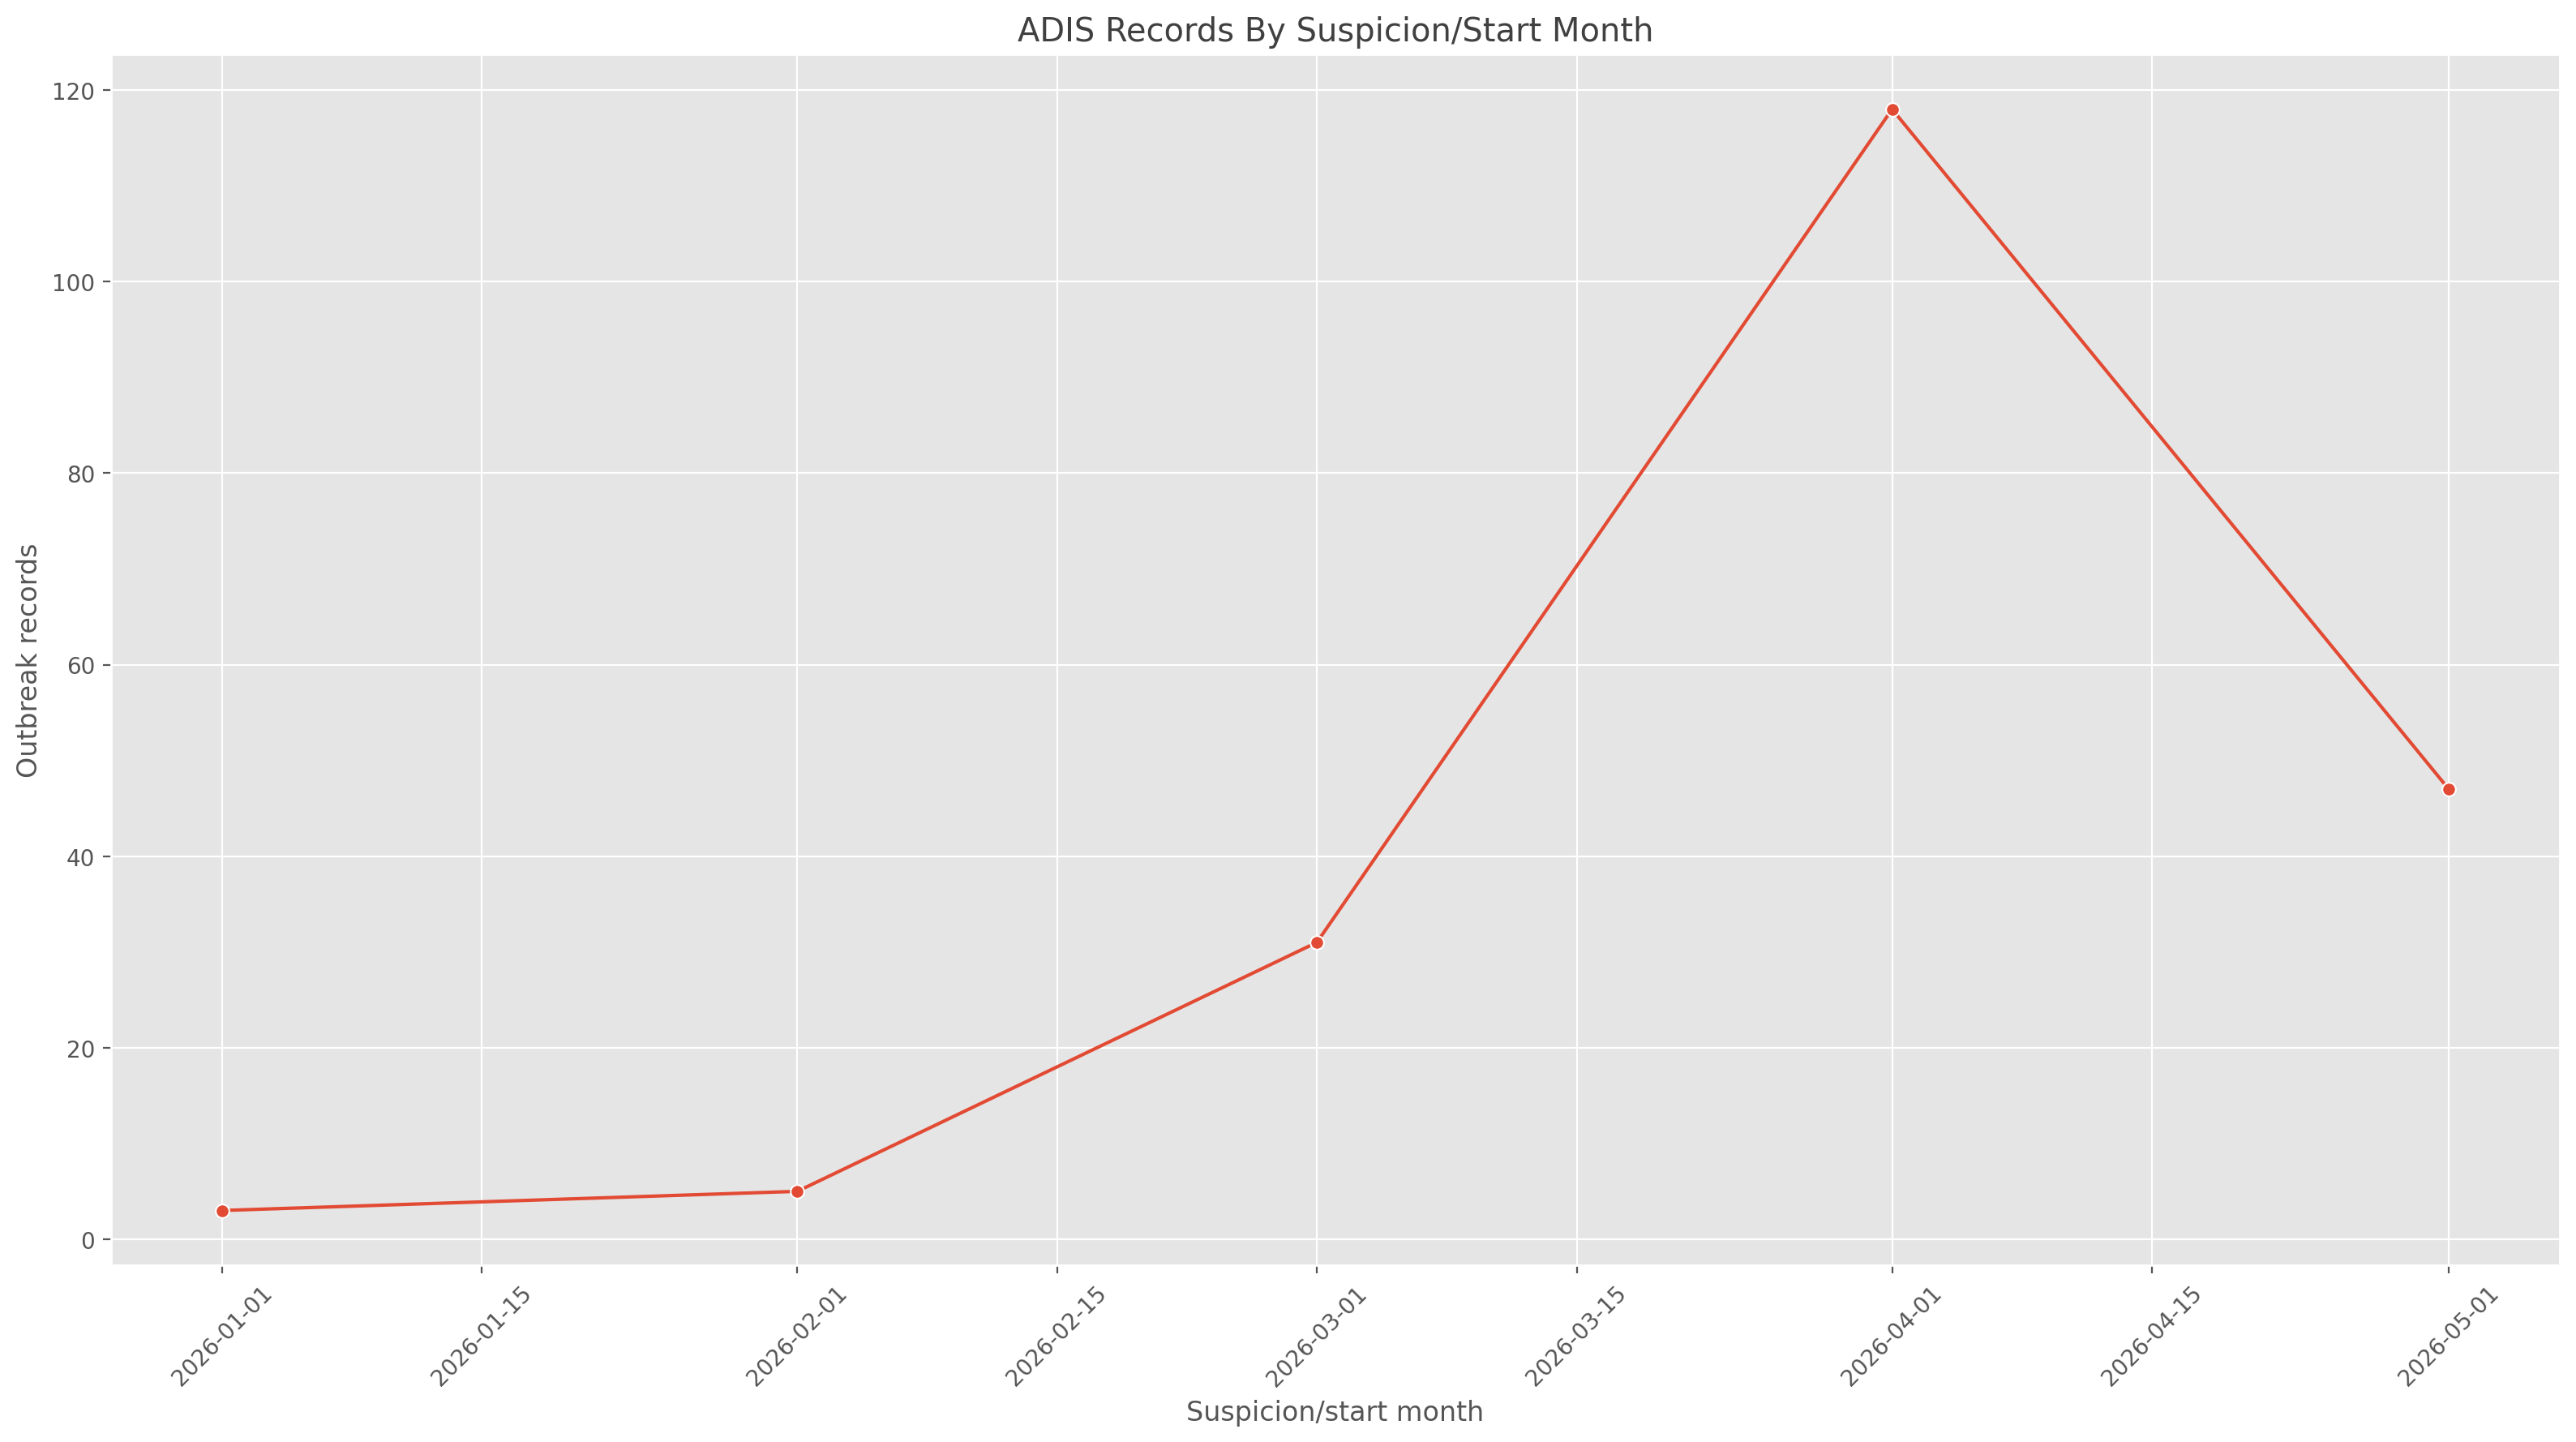

In [7]:
events_by_month = monthly_counts(df, "Suspicion/Start date", label="outbreak_records")

sns.lineplot(data=events_by_month, x="month", y="outbreak_records", marker="o")
plt.title("ADIS Records By Suspicion/Start Month")
plt.xlabel("Suspicion/start month")
plt.ylabel("Outbreak records")
plt.xticks(rotation=45)
plt.tight_layout()

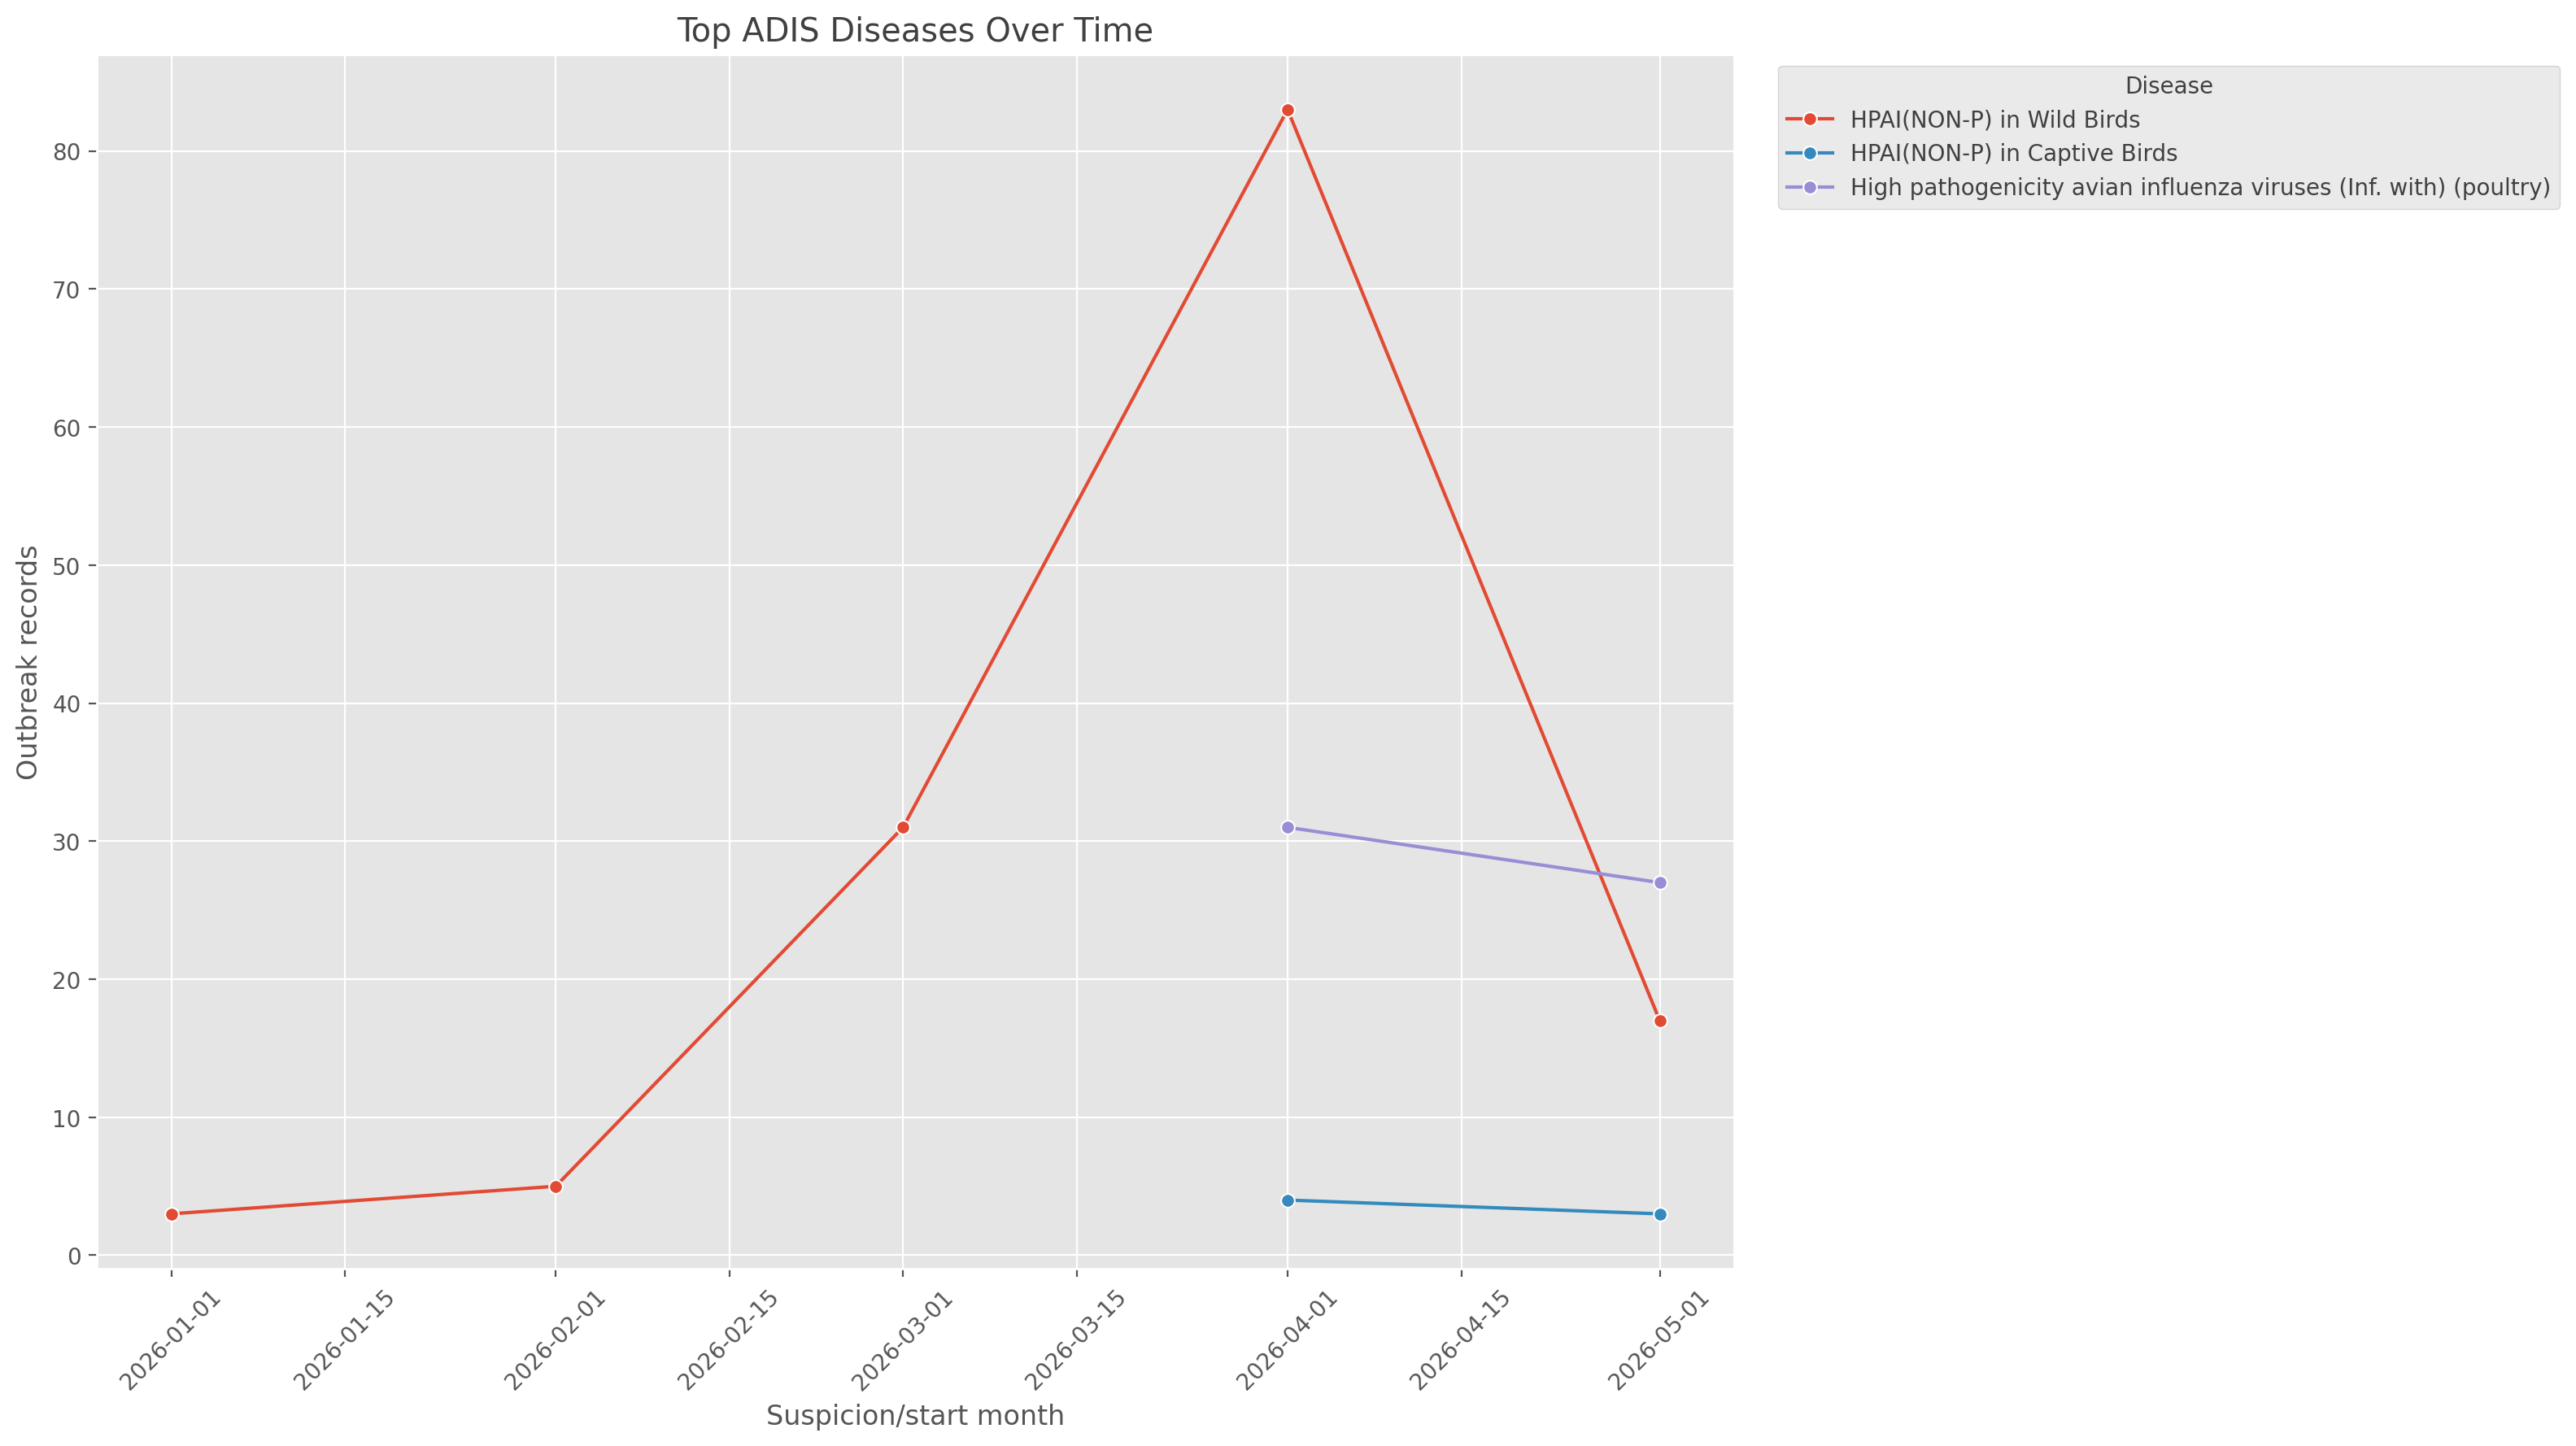

In [8]:
events_by_month_and_disease = monthly_counts_by_category(
    df,
    date_column="Suspicion/Start date",
    category_column="Disease name",
    top_n=6,
    label="outbreak_records",
)

sns.lineplot(
    data=events_by_month_and_disease,
    x="month",
    y="outbreak_records",
    hue="Disease name",
    marker="o",
)
plt.title("Top ADIS Diseases Over Time")
plt.xlabel("Suspicion/start month")
plt.ylabel("Outbreak records")
plt.xticks(rotation=45)
plt.legend(title="Disease", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Delay Analysis


,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
confirmation_delay_days,204.0,9.235294,12.561711,0.0,1.0,1.0,7.0,12.0,18.7,22.0,112.0
submission_delay_days,204.0,7.401961,14.670946,0.0,1.0,1.0,3.0,6.0,15.7,32.0,109.0
outbreak_duration_days,139.0,10.791367,12.923114,0.0,2.0,4.5,8.0,14.0,21.2,23.4,112.0


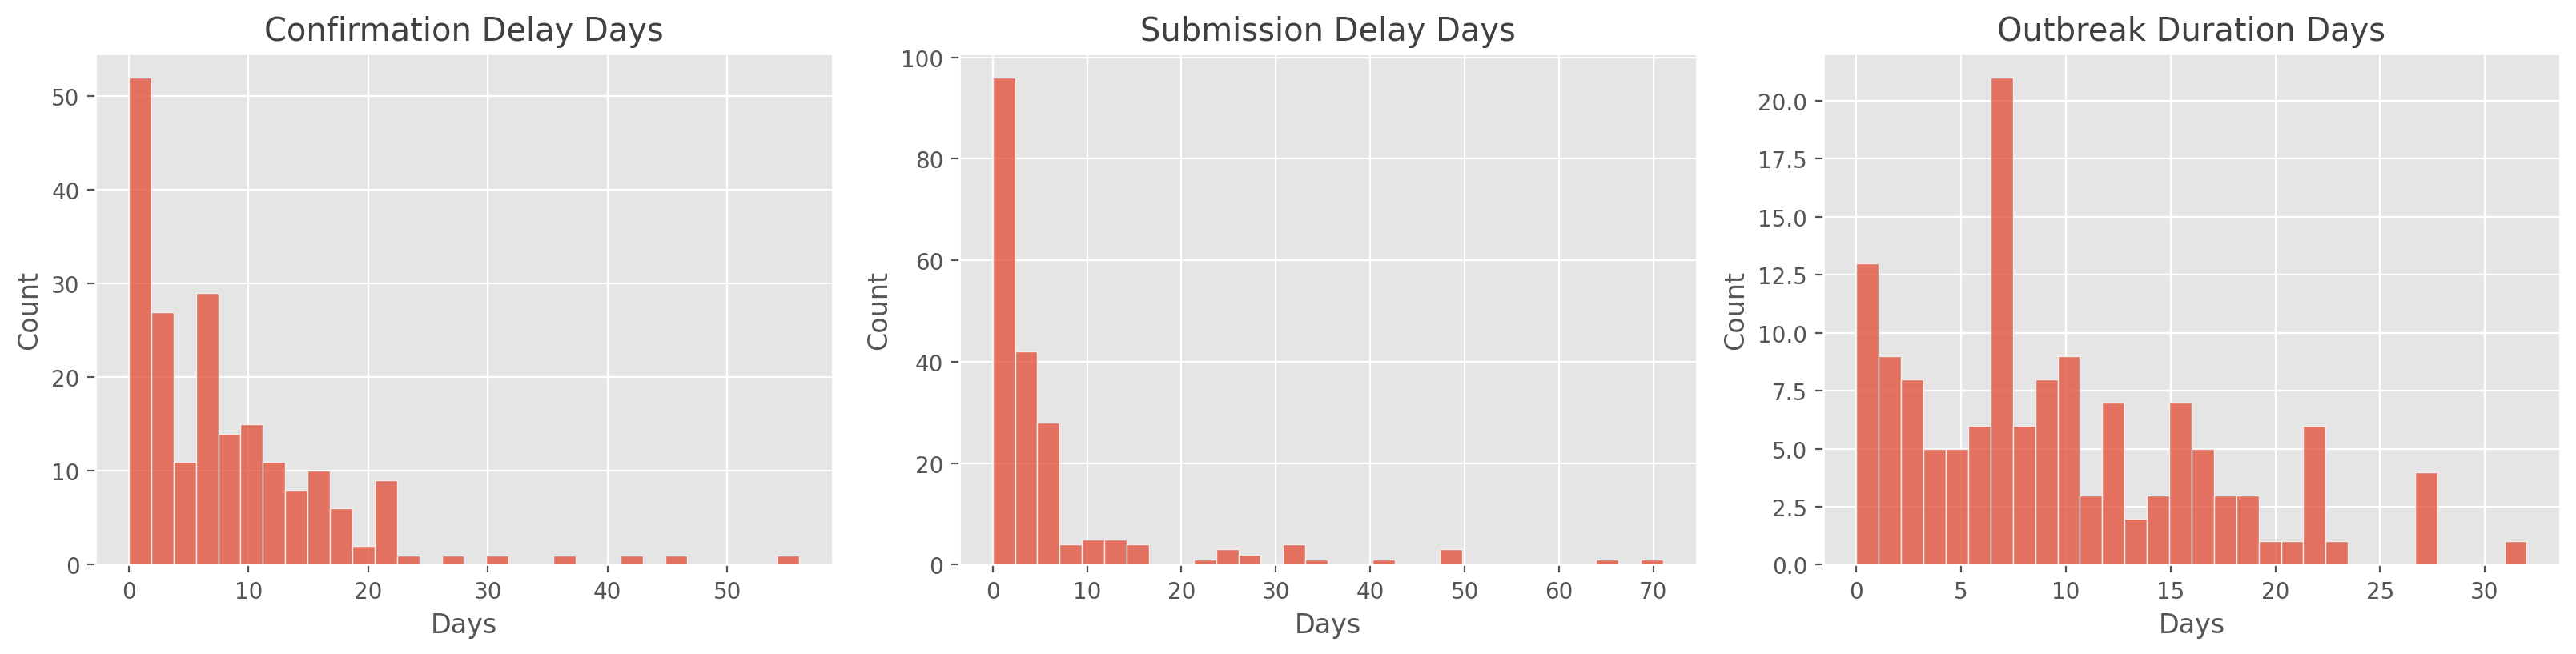

In [9]:
delay_columns = [
    "confirmation_delay_days",
    "submission_delay_days",
    "outbreak_duration_days",
]

display(df[delay_columns].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).T)

fig, axes = plt.subplots(1, len(delay_columns), figsize=(5.4 * len(delay_columns), 4.2))
for axis, column in zip(axes, delay_columns):
    values = df[column].dropna()
    if not values.empty:
        values = values[
            (values >= values.quantile(0.01)) & (values <= values.quantile(0.99))
        ]
    sns.histplot(values, bins=30, ax=axis)
    axis.set_title(column.replace("_", " ").title())
    axis.set_xlabel("Days")
plt.tight_layout()

In [10]:
df.loc[
    df[delay_columns].notna().any(axis=1),
    [
        "Country/Territory",
        "Disease name",
        "Suspicion/Start date",
        "Confirmation date",
        "Submitted on",
        *delay_columns,
    ],
].sort_values("confirmation_delay_days", ascending=False).head(20)

,Country/Territory,Disease name,Suspicion/Start date,Confirmation date,Submitted on,confirmation_delay_days,submission_delay_days,outbreak_duration_days
1201,Belgien,HPAI(NON-P) in Wild Birds,2026-01-19,2026-05-11,2026-05-12,112,1,112.0
845,Dänemark,HPAI(NON-P) in Wild Birds,2026-02-18,2026-05-01,2026-05-08,72,7,0.0
846,Dänemark,HPAI(NON-P) in Wild Birds,2026-02-24,2026-05-01,2026-05-08,66,7,0.0
639,Schweden,HPAI(NON-P) in Wild Birds,2026-03-03,2026-04-28,2026-04-30,56,2,0.0
203,Frankreich,HPAI(NON-P) in Wild Birds,2026-03-06,2026-04-20,2026-04-22,45,2,NaN
1312,Niederlande,HPAI(NON-P) in Wild Birds,2026-04-01,2026-05-13,2026-05-16,42,3,NaN
847,Dänemark,HPAI(NON-P) in Wild Birds,2026-03-25,2026-05-01,2026-05-08,37,7,0.0
5,Deutschland,HPAI(NON-P) in Wild Birds,2026-02-02,2026-03-04,2026-05-07,30,64,8.0
606,Deutschland,HPAI(NON-P) in Wild Birds,2026-04-01,2026-04-28,2026-05-07,27,9,27.0
433,Deutschland,HPAI(NON-P) in Wild Birds,2026-03-31,2026-04-23,2026-04-28,23,5,23.0


## Country-Disease Matrix


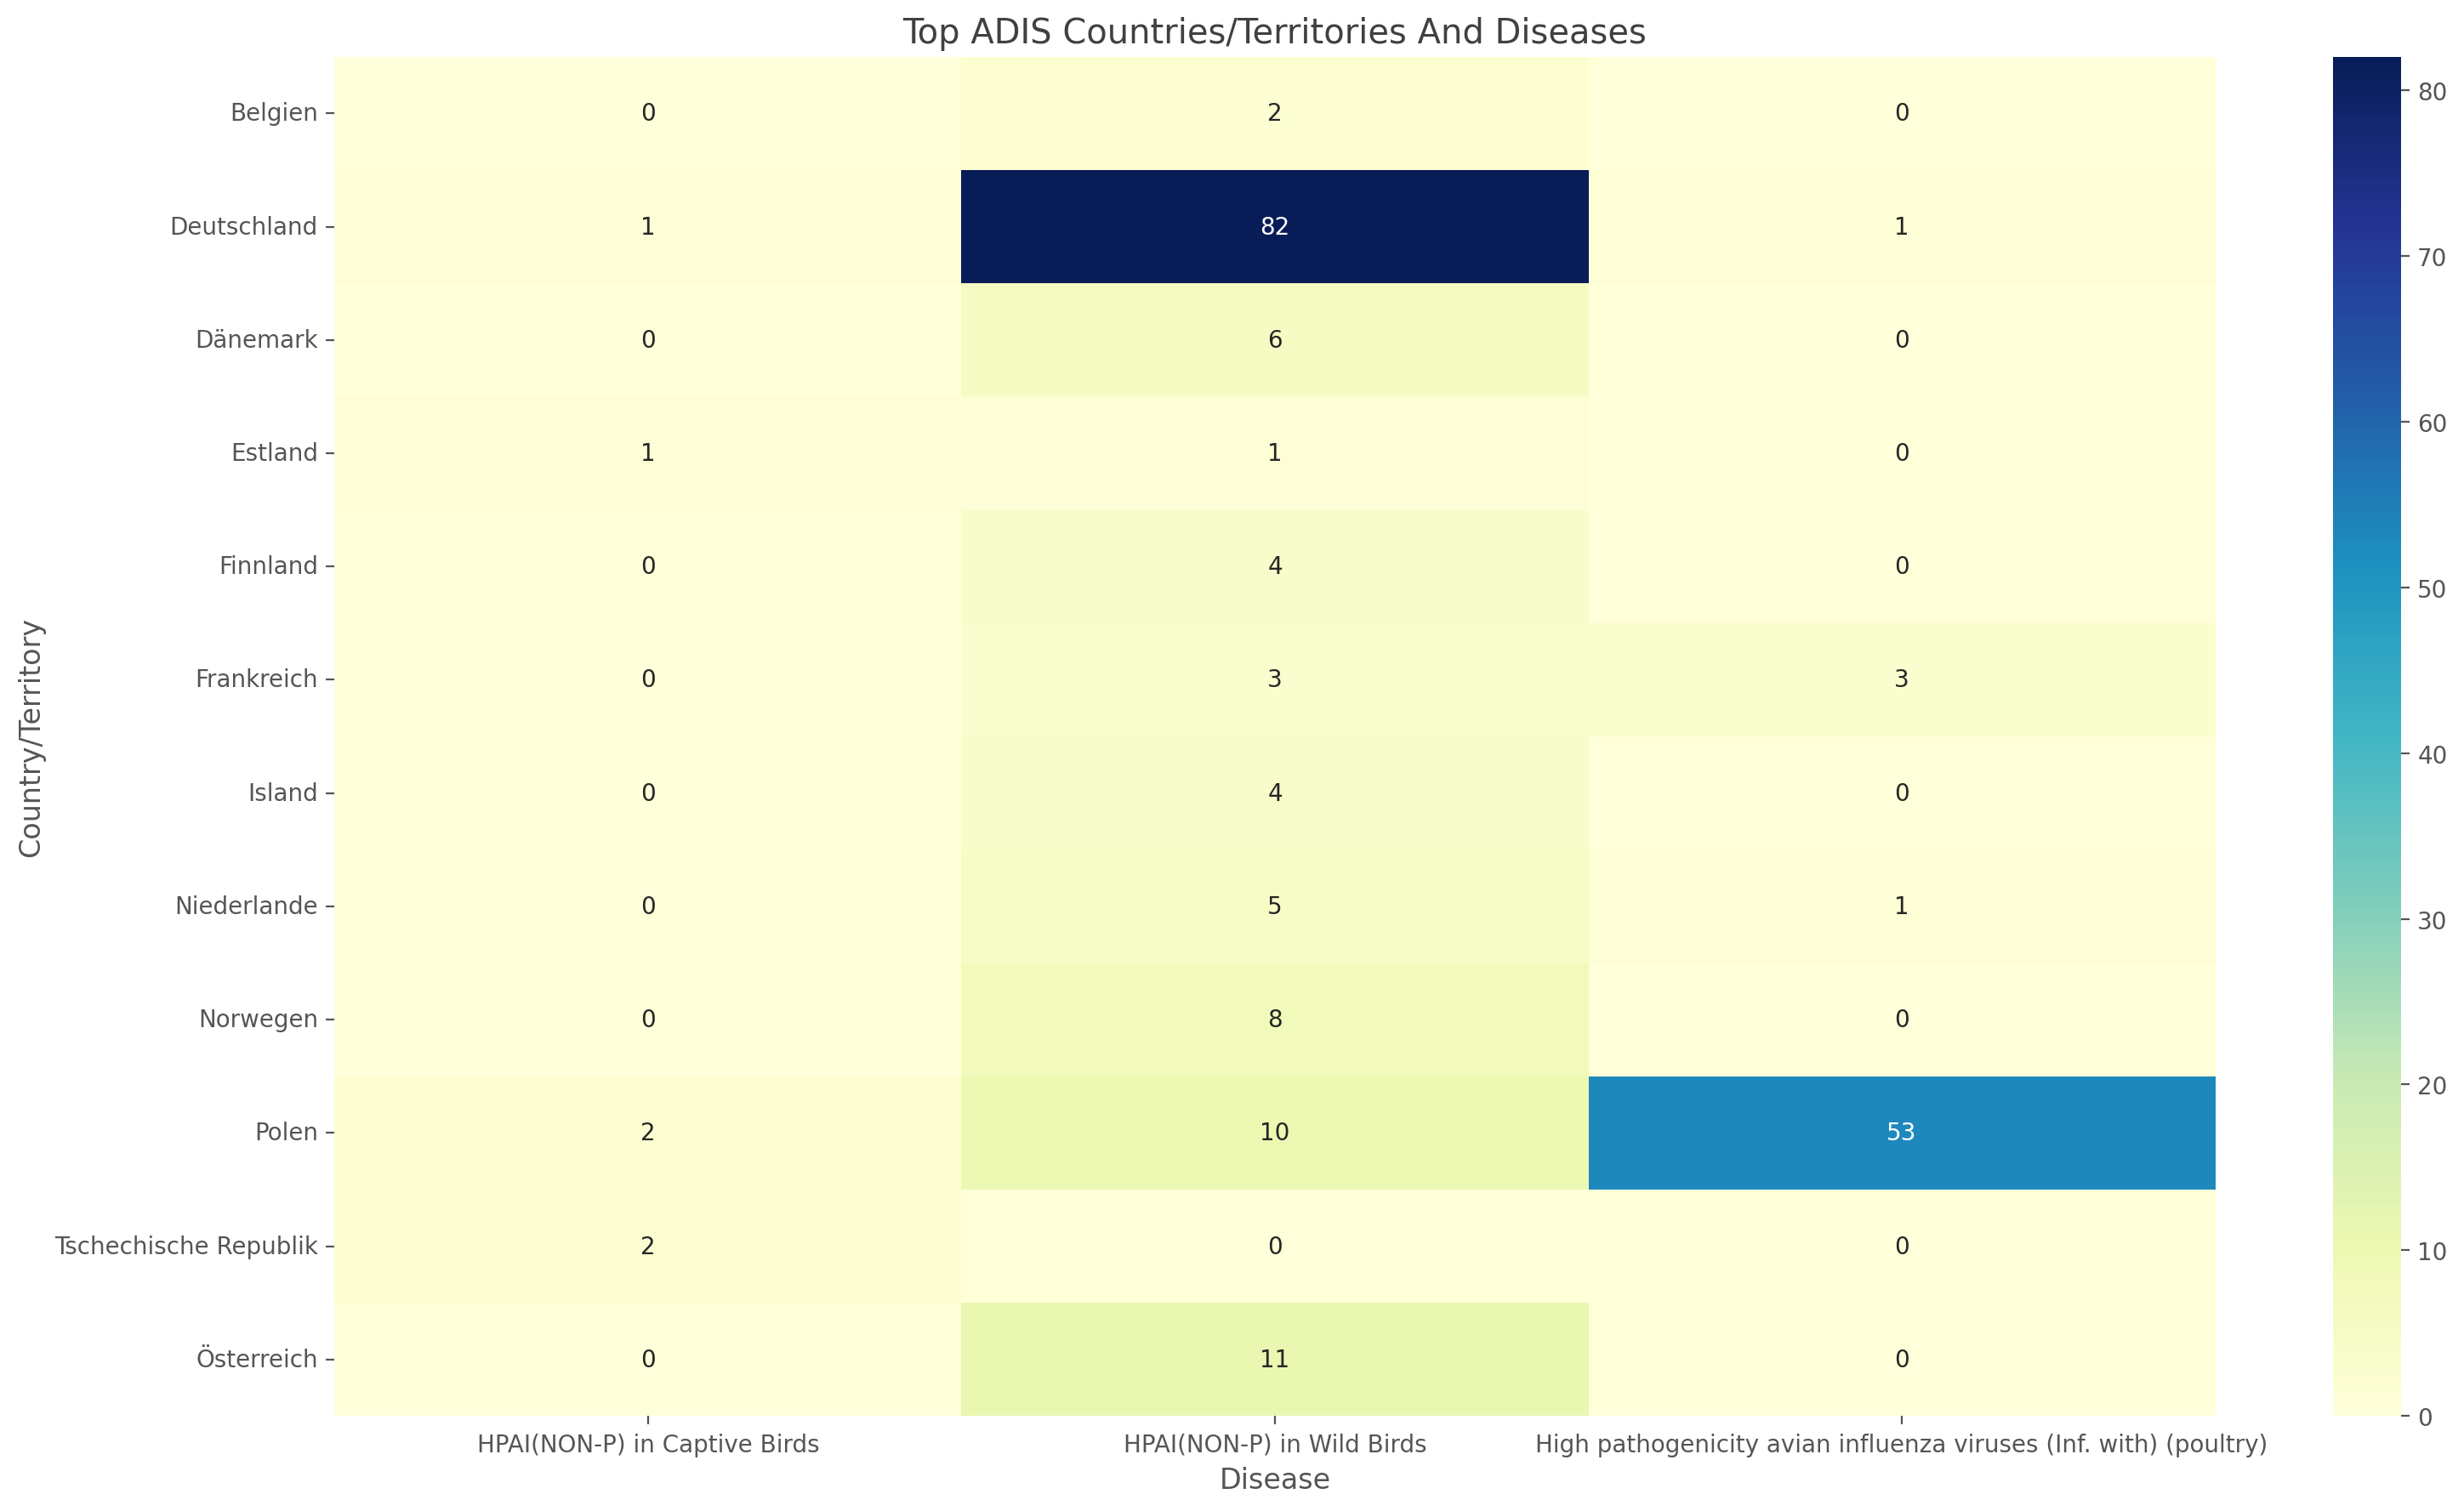

In [11]:
matrix = country_disease_matrix(df, "Country/Territory", "Disease name")

sns.heatmap(matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Top ADIS Countries/Territories And Diseases")
plt.xlabel("Disease")
plt.ylabel("Country/Territory")
plt.tight_layout()

## Geographic Snapshot

Map HPAI outbreak coordinates on a basemap. This cell uses `contextily` basemap tiles when executed; set `BASEMAP_SOURCE` in the setup cell if another provider is preferred.

,Longitude,Latitude
count,204.000000,204.000000
mean,13.022535,53.001261
std,7.639079,4.196203
min,-22.565944,40.508903
25%,9.082500,51.602500
50%,12.398658,52.702266
75%,19.516230,53.580000
max,30.045100,69.601000


,Country/Territory,Disease name,Disease type,Latitude,Longitude
1,Deutschland,HPAI(NON-P) in Wild Birds,H5N1,51.410000,7.35000
2,Deutschland,HPAI(NON-P) in Wild Birds,H5N1,50.910000,10.01000
3,Island,HPAI(NON-P) in Wild Birds,H5N1,64.139686,-21.96424
4,Island,HPAI(NON-P) in Wild Birds,H5N1,64.155561,-21.96285
5,Deutschland,HPAI(NON-P) in Wild Birds,H5N1,51.610000,7.50000


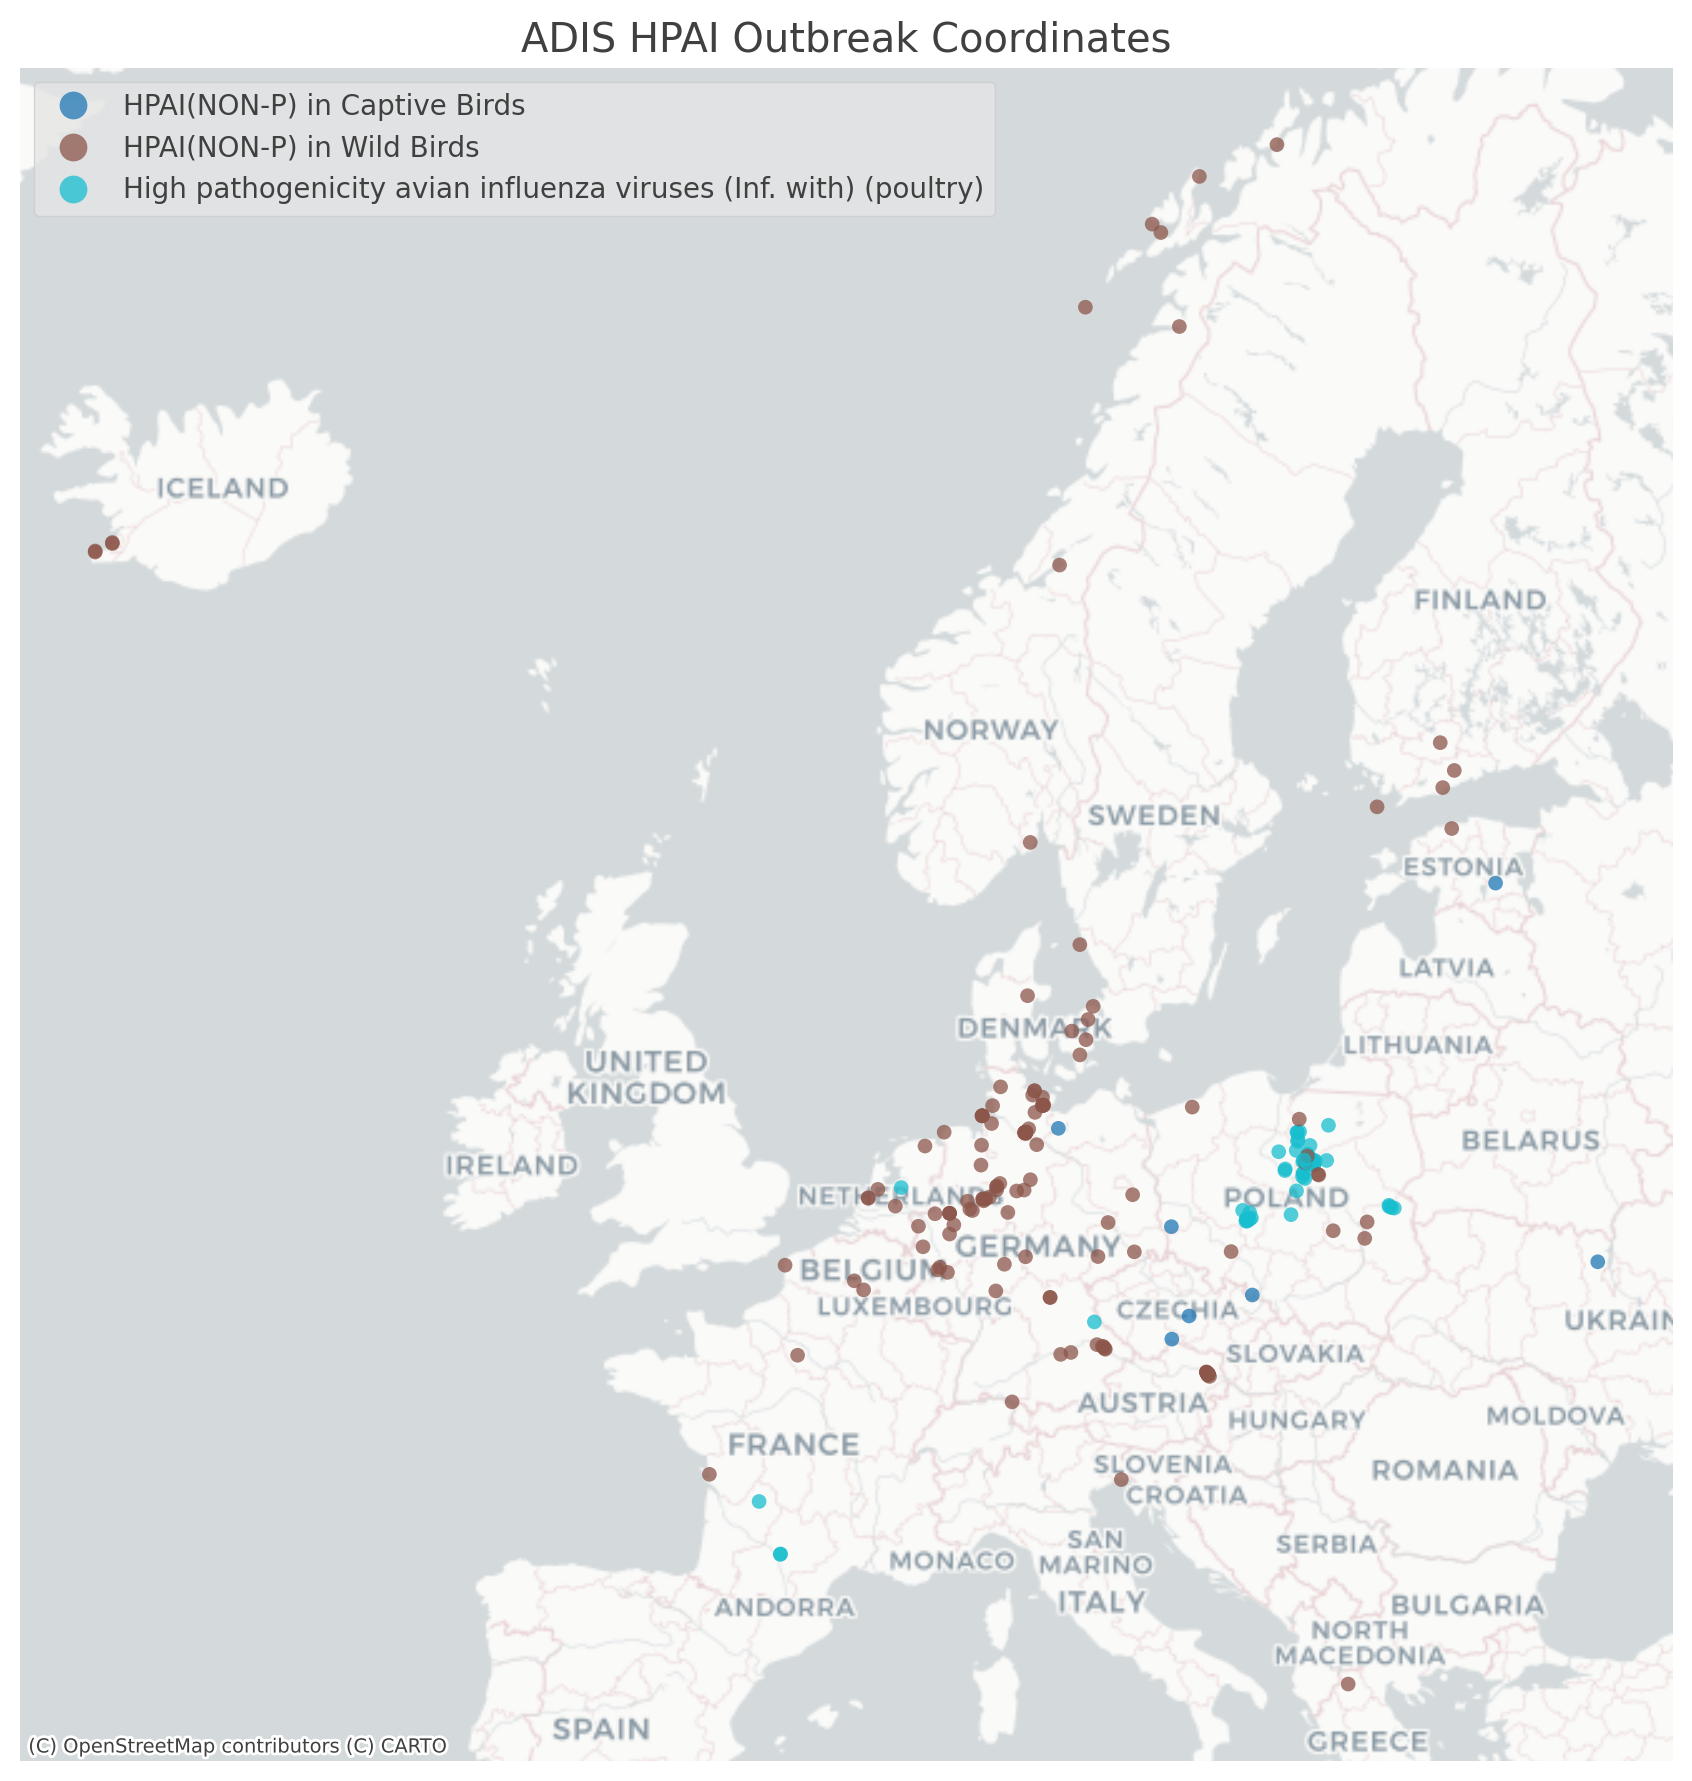

In [12]:
geo_df = df.dropna(subset=['Longitude', 'Latitude']).copy()

display(geo_df[['Longitude', 'Latitude']].describe())

mapped_events = plot_event_map(
    geo_df,
    longitude_column='Longitude',
    latitude_column='Latitude',
    color_column='Disease name',
    title='ADIS HPAI Outbreak Coordinates',
    marker_size=28,
    alpha=0.75,
)

mapped_events[['Country/Territory', 'Disease name', 'Disease type', 'Latitude', 'Longitude']].head()

## Source-Specific Signals

ADIS includes outbreak burden, continuing/resolved status, diagnostic evidence, and administrative divisions.


In [13]:
burden_columns = [
    "Susceptible 1",
    "Cases 1",
    "Dead 1",
    "Killed 1",
    "Slaughtered 1",
    "Vaccinated 1",
    "total_affected_or_removed",
]

display(df[burden_columns].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T)

source_specific = {
    "continuing_by_country": pd.crosstab(
        df["Country/Territory"], df["Status Continuing/Resolved"], dropna=False
    ).sort_index(),
    "diagnostics_by_disease": pd.crosstab(
        df["Disease name"], df["Diagnostic tests"], dropna=False
    ),
    "top_admin1": top_counts(df, "Administrative division level 1", 20),
    "restricted_zone_by_disease": pd.crosstab(
        df["Disease name"],
        df["Outbreak occurring inside an already restricted zone"],
        dropna=False,
    ),
}

display(source_specific["continuing_by_country"].tail(20))
display(source_specific["diagnostics_by_disease"].head(20))
display(source_specific["top_admin1"])
display(source_specific["restricted_zone_by_disease"].head(20))

,count,mean,std,min,50%,75%,90%,95%,99%,max
Susceptible 1,65.0,52794.707692,125922.729608,8.0,19271.0,41237.00,86457.0,257035.0,679478.96,707726.0
Cases 1,199.0,16899.236181,75756.748898,1.0,1.0,4246.00,30221.2,58964.5,312642.20,707726.0
Dead 1,202.0,213.470297,1847.038536,0.0,1.0,19.75,300.0,595.0,1268.31,26100.0
Killed 1,139.0,22049.424460,89710.114099,0.0,0.0,5959.00,35879.0,84306.2,527191.60,707346.0
Slaughtered 1,91.0,0.000000,0.000000,0.0,0.0,0.00,0.0,0.0,0.00,0.0
Vaccinated 1,90.0,0.000000,0.000000,0.0,0.0,0.00,0.0,0.0,0.00,0.0
total_affected_or_removed,204.0,31720.289216,149303.715750,1.0,2.0,6815.25,49550.8,91992.3,610339.90,1415452.0


Status Continuing/Resolved,Continuing,Resolved
Country/Territory,,
Belgien,0,2
Deutschland,6,78
Dänemark,0,6
Estland,1,1
Finnland,0,4
Frankreich,5,1
Griechenland,0,1
Island,2,2
Italien,0,1


Diagnostic tests,NaN
Disease name,
HPAI(NON-P) in Captive Birds,7
HPAI(NON-P) in Wild Birds,139
High pathogenicity avian influenza viruses (Inf. with) (poultry),58


,Administrative division level 1,records
0,Mazowieckie,31
1,Nordrhein-Westfalen,22
2,Hamburg,20
3,Schleswig-Holstein,12
4,Wielkopolskie,11
5,Niedersachsen,10
6,Bayern,10
7,Warmińsko-Mazurskie,8
8,Wien,8
9,Lubelskie,6


Outbreak occurring inside an already restricted zone,NaN
Disease name,
HPAI(NON-P) in Captive Birds,7
HPAI(NON-P) in Wild Birds,139
High pathogenicity avian influenza viruses (Inf. with) (poultry),58


## Quick Filters

Set any filter to a string value, or leave it as `None` to ignore that filter.


In [14]:
country_filter = None
disease_filter = None
status_filter = None
species_filter = None

filtered = df.copy()
if country_filter:
    filtered = filtered[filtered["Country/Territory"].eq(country_filter)]
if disease_filter:
    filtered = filtered[filtered["Disease name"].eq(disease_filter)]
if status_filter:
    filtered = filtered[filtered["Status Continuing/Resolved"].eq(status_filter)]
if species_filter:
    filtered = filtered[filtered["Species 1"].eq(species_filter)]

filtered.sort_values("Submitted on", ascending=False).head(50)

,Reference,National reference,Country/Territory,Typ,Disease name,Disease type,Epidemiological unit,Submitted on,Modified on,Administrative division level 1,Administrative division level 2,Administrative division level 3,Outbreak occurring inside an already restricted zone,Latitude,Longitude,Approximate location,Location,Wildlife type 1,Production Type 1,Water type 1,Production system 1,Measuring unit 1,Susceptible 1,Cases 1,Dead 1,Killed 1,Slaughtered 1,Vaccinated 1,Outbreak year,Suspicion/Start date,Confirmation date,End date,Status Continuing/Resolved,Suspicion,Clinical signs,Diagnostic tests,Necropsy,Category 1,Subcategory 1,Test name 1,Test type 1,Laboratory type 1,Species 1,Result date 1,Result type 1,Pertinence,confirmation_delay_days,submission_delay_days,outbreak_duration_days,total_affected_or_removed
1,DE-HPAI(NON-P)-2026-xsyaz,26-015-a0jke,Deutschland,Primary,HPAI(NON-P) in Wild Birds,H5N1,Not applicable,2026-05-19,2026-05-19,Nordrhein-Westfalen,Ennepe-Ruhr-Kreis,Witten,NaN,51.410000,7.350000,NaN,Witten,Wild,NaN,NaN,NaN,Tiere,NaN,1.0,1.0,0.0,0.0,0.0,2026,2026-01-27,2026-01-30,2026-01-30,Resolved,NaN,NaN,NaN,NaN,Pathogen detection,Nucleic acid detection,Real-time polymerase chain reaction (real-time...,Laboratory,Private Laboratory,Anser anser,2026-01-30,Positive,EU and WOAH,3,109,3.0,2.0
851,DE-HPAI(NON-P)-2026-nbc5q,26-015-4zpqr,Deutschland,Primary,HPAI(NON-P) in Wild Birds,H5N1,Not applicable,2026-05-19,2026-05-19,Nordrhein-Westfalen,Rhein-Sieg-Kreis,Rheinbach,NaN,50.620000,6.930000,NaN,Rheinbach,Wild,NaN,NaN,NaN,Tiere,NaN,1.0,1.0,0.0,0.0,0.0,2026,2026-04-21,2026-05-04,2026-05-07,Resolved,NaN,NaN,NaN,NaN,Pathogen detection,Nucleic acid detection,Real-time polymerase chain reaction (real-time...,Laboratory,Private Laboratory,Anser anser,2026-05-04,Positive,EU and WOAH,13,15,16.0,2.0
1407,PL-HPAI(NON-P)-2026-pntkm,2026/16c-5nw1y,Polen,Primary,HPAI(NON-P) in Captive Birds,H5N1,Backyard,2026-05-19,2026-05-19,Opolskie,Głubczyce,Kietrz,NaN,50.058642,17.949986,NaN,Dzierżysław,NaN,Non-poultry birds,NaN,NaN,Tiere,46.0,46.0,46.0,NaN,NaN,NaN,2026,2026-05-16,2026-05-18,NaT,Continuing,NaN,NaN,NaN,NaN,Pathogen detection,Nucleic acid detection,Real-time reverse transcription polymerase cha...,Laboratory,National Reference Laboratory,Birds,2026-05-18,Positive,EU and WOAH,2,1,NaN,92.0
1295,DE-HPAI(NON-P)-2026-8fv4x,26-015-azdy8,Deutschland,Primary,HPAI(NON-P) in Wild Birds,H5N1,Not applicable,2026-05-19,2026-05-19,Hamburg,Hamburg,Hamburg,NaN,53.920000,8.490000,NaN,Hamburg,Wild,NaN,NaN,NaN,Tiere,NaN,1.0,1.0,0.0,0.0,0.0,2026,2026-05-06,2026-05-13,2026-05-13,Resolved,NaN,NaN,NaN,NaN,Pathogen detection,Nucleic acid detection,Polymerase chain reaction (PCR),Laboratory,Private Laboratory,Branta bernicla,2026-05-12,Positive,EU and WOAH,7,6,7.0,2.0
1294,DE-HPAI(NON-P)-2026-54n9n,26-015-smwte,Deutschland,Primary,HPAI(NON-P) in Wild Birds,H5N1,Not applicable,2026-05-19,2026-05-19,Hamburg,Hamburg,Hamburg,NaN,53.920000,8.490000,NaN,Hamburg,Wild,NaN,NaN,NaN,Tiere,NaN,1.0,1.0,0.0,0.0,0.0,2026,2026-05-06,2026-05-13,2026-05-13,Resolved,NaN,NaN,NaN,NaN,Pathogen detection,Nucleic acid detection,Polymerase chain reaction (PCR),Laboratory,Private Laboratory,Branta leucopsis,2026-05-12,Positive,EU and WOAH,7,6,7.0,2.0
1293,DE-HPAI(NON-P)-2026-364i1,26-015-k9h21,Deutschland,Primary,HPAI(NON-P) in Wild Birds,H5N1,Not applicable,2026-05-19,2026-05-19,Hamburg,Hamburg,Hamburg,NaN,53.920000,8.500000,NaN,Hamburg,Wild,NaN,NaN,NaN,Tiere,NaN,1.0,1.0,0.0,0.0,0.0,2026,2026-05-06,2026-05-13,2026-05-13,Resolved,NaN,NaN,NaN,NaN,Pathogen detection,Nucleic acid detection,Polymerase chain reaction (PCR),Laboratory,Private Laboratory,Branta bernicla,2026-05-12,Positive,EU and WOAH,7,6,7.0,2.0
1292,DE-HPAI(NON-P)-2026-nqg4e,26-015-0ihz6,Deutschland,Primary,HPAI(NON-P) in Wild Birds,H5N1,Not applicable,2026-05-19,2026-05-19,Hamburg,Hamburg,Hamburg,NaN,53.920000,8.490000,NaN,Hamburg,Wild,NaN,NaN,NaN,Tiere,NaN,1.0,1.0,0.0,0.0,0.0,2026,2026-05-06,2026-05-13,2026-05-13,Resolv